## 1. Импорт библиотек и загрузка данных по двум акциям США

В этом задании нужно выбрать две компании с листингом на фондовом рынке США
и выгрузить **дневные данные с 2017 года**. В качестве источника данных удобно
использовать библиотеку `yfinance`, которая загружает котировки с Yahoo Finance
прямо в pandas:

1. Подключаем библиотеки `pandas`, `numpy`, `matplotlib` и `yfinance`.
2. Выбираем два тикера американских компаний (например, `AAPL` и `GOOG`).
3. Скачиваем дневные котировки, начиная с 2017-01-01 по текущую дату.
4. Формируем датафрейм с ценами закрытия (`Close`) для обоих тикеров,
   чтобы дальше анализировать их как два временных ряда.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf  # библиотека для загрузки данных с Yahoo Finance

pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)

# 1. Задаём параметры выгрузки
start_date = "2017-01-01"
end_date = None  # если None, то данные будут до сегодняшней даты

# 2. Выбираем два тикера (можешь потом заменить на свои, если нужно)
ticker_1 = "AAPL"  # Apple Inc.
ticker_2 = "GOOG"  # Alphabet Inc. (Google)
tickers = [ticker_1, ticker_2]

# 3. Загружаем дневные данные по каждому тикеру
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True,
    group_by="ticker"  # данные будут сгруппированы по тикерам
)

# 4. Собираем цены закрытия в единый датафрейм
close_df = pd.DataFrame()

for t in tickers:
    close_df[t] = data[t]["Close"]

close_df.index.name = "Date"

# 5. Смотрим базовую информацию
print("Первые строки цен закрытия:")
print(close_df.head())

print("\nИнформация о датафрейме с ценами закрытия:")
print(close_df.info())

print("\nБазовые статистики по ценам закрытия:")
print(close_df.describe())

[*********************100%***********************]  2 of 2 completed

Первые строки цен закрытия:
                 AAPL       GOOG
Date                            
2017-01-03  26.721235  38.986916
2017-01-04  26.691324  39.024609
2017-01-05  26.827061  39.377716
2017-01-06  27.126135  39.979271
2017-01-09  27.374598  40.004074

Информация о датафрейме с ценами закрытия:
<class 'pandas.DataFrame'>
DatetimeIndex: 2357 entries, 2017-01-03 to 2026-05-19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2357 non-null   float64
 1   GOOG    2357 non-null   float64
dtypes: float64(2)
memory usage: 55.2 KB
None

Базовые статистики по ценам закрытия:
              AAPL         GOOG
count  2357.000000  2357.000000
mean    129.820881   116.192435
std      74.340979    70.256434
min      26.691324    38.986916
25%      49.439285    58.388634
50%     137.171921   103.004326
75%     183.562195   144.939072
max     300.230011   399.040009


## Выводы

1. Для анализа выбраны две акции американских компаний: `AAPL` (Apple Inc.) и `GOOG` (Alphabet Inc.). Для обеих бумаг удалось успешно загрузить дневные котировки с помощью библиотеки `yfinance` начиная с 2017-01-03 по текущую дату.

2. Итоговый датафрейм `close_df` содержит 2357 наблюдений по каждой акции. Индексом выступает дата (`Date`), а столбцы — цены закрытия `AAPL` и `GOOG`. Пропусков в данных нет: количество ненулевых значений по каждому столбцу совпадает с общим числом строк.

3. Базовые статистики показывают, что средняя цена закрытия для `AAPL` за период составляет примерно 129.8, а для `GOOG` — около 116.2. Диапазон цен довольно широкий: у `AAPL` от ~26.7 до ~300.2, у `GOOG` от ~39.0 до ~399.0. Это говорит о существенном росте обоих активов за рассматриваемый период.

## 2. Исследовательский анализ цен и доходностей

1. Построим графики цен закрытия для `AAPL` и `GOOG` на одном поле.
2. Посчитаем дневные логарифмические доходности для обеих акций.
3. Посмотрим на базовые статистики доходностей и их распределения (гистограммы).

Лог-доходности удобны тем, что:
- они симметричнее обычных доходностей;
- хорошо складываются по времени;
- часто ближе к нормальному распределению.

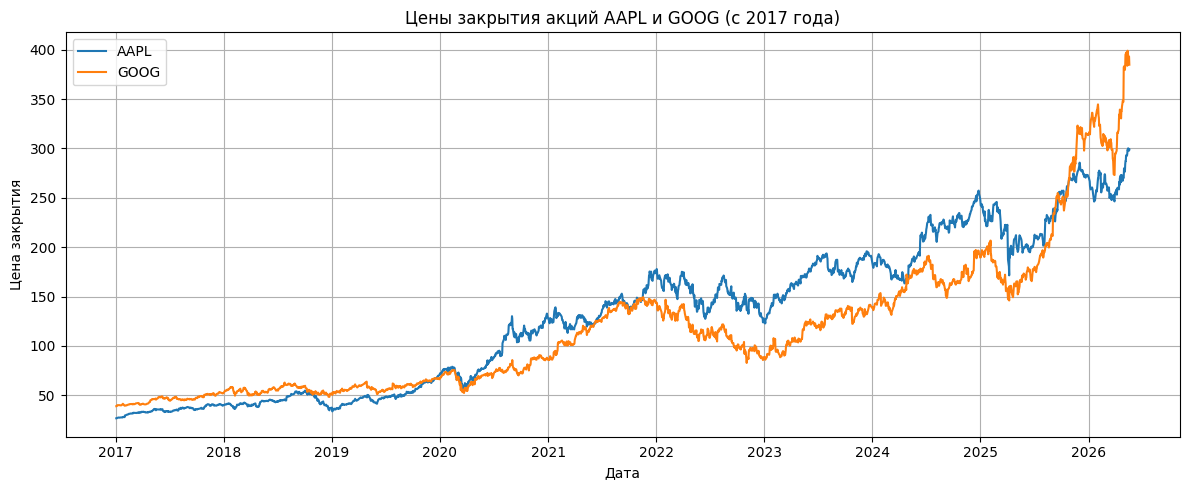

Первые строки лог-доходностей:
                AAPL      GOOG
Date                          
2017-01-04 -0.001120  0.000966
2017-01-05  0.005073  0.009008
2017-01-06  0.011087  0.015161
2017-01-09  0.009118  0.000620
2017-01-10  0.001008 -0.002309

Базовые статистики лог-доходностей:
              AAPL         GOOG
count  2356.000000  2356.000000
mean      0.001025     0.000972
std       0.018515     0.018638
min      -0.137708    -0.117667
25%      -0.007338    -0.007625
50%       0.001139     0.001475
75%       0.010169     0.010553
max       0.142618     0.099379


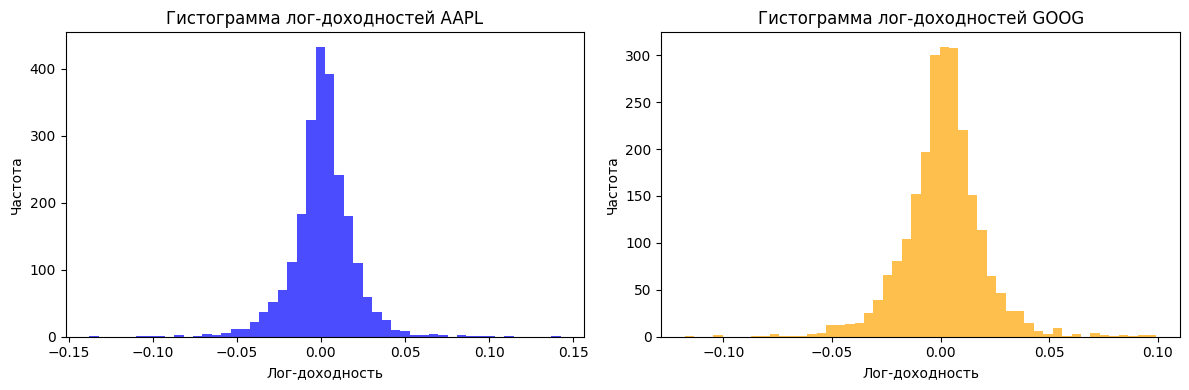

In [3]:
# 1. График цен закрытия
plt.figure(figsize=(12, 5))
plt.plot(close_df.index, close_df["AAPL"], label="AAPL")
plt.plot(close_df.index, close_df["GOOG"], label="GOOG")
plt.title("Цены закрытия акций AAPL и GOOG (с 2017 года)")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Дневные лог-доходности
log_returns = np.log(close_df / close_df.shift(1)).dropna()

print("Первые строки лог-доходностей:")
print(log_returns.head())

print("\nБазовые статистики лог-доходностей:")
print(log_returns.describe())

# 3. Гистограммы лог-доходностей
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(log_returns["AAPL"], bins=50, alpha=0.7, color="blue")
plt.title("Гистограмма лог-доходностей AAPL")
plt.xlabel("Лог-доходность")
plt.ylabel("Частота")

plt.subplot(1, 2, 2)
plt.hist(log_returns["GOOG"], bins=50, alpha=0.7, color="orange")
plt.title("Гистограмма лог-доходностей GOOG")
plt.xlabel("Лог-доходность")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

## Выводы (цены и лог-доходности)

1. Графики цен закрытия `AAPL` и `GOOG` с 2017 года показывают общий восходящий тренд: обе акции значительно выросли за рассматриваемый период. При этом на графике хорошо видны периоды коррекций и просадок (например, вокруг 2020 года), после которых цены продолжали расти.

2. По дневным логарифмическим доходностям средние значения для обеих акций положительные и небольшие: около 0.0010–0.0011, что соответствует среднему дневному росту примерно 0.1%. Стандартное отклонение доходностей примерно 0.018–0.019, то есть типичный дневной разброс доходностей находится в районе ±2%.

3. Минимальные и максимальные лог-доходности имеют заметные «хвосты»: для `AAPL` от примерно -13.8% до +14.3%, для `GOOG` от примерно -11.8% до +9.9%. Это отражает наличие редких, но сильных движений цены (волатильность в кризисные периоды и на важных новостях).

4. Гистограммы лог-доходностей визуально напоминают колоколообразное распределение, сосредоточенное вокруг нуля, но с более тяжёлыми хвостами, чем у идеальной нормальной кривой. Это типичная картина для финансовых временных рядов: большинство дневных доходностей небольшие, но иногда происходят экстремальные скачки.

5. Для дальнейшего анализа удобнее работать именно с лог-доходностями, так как они ближе к стационарному процессу (нет явного тренда в среднем уровне), а также их проще использовать при построении моделей и расчёте ризиковых метрик.

## 3. Проверка стационарности лог-доходностей

Цены акций сами по себе обычно нестационарны (имеют тренд),
поэтому для анализа и моделирования часто используют доходности:

1. Проведём ADF-тест на стационарность лог-доходностей `AAPL` и `GOOG`.
2. Посмотрим на значения p-value и сравним их с уровнем значимости 0.05.
3. Сформулируем вывод, можно ли считать лог-доходности стационарными.

In [4]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=""):
    print(f"ADF-тест для: {title}")
    result = adfuller(series.dropna())
    labels = ["ADF-статистика", "p-value", "lags", "n_obs"]
    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")
    for key, val in result[4].items():
        print(f"Критическое значение ({key}): {val}")
    print("-" * 50)

adf_test(log_returns["AAPL"], title="лог-доходности AAPL")
adf_test(log_returns["GOOG"], title="лог-доходности GOOG")

ADF-тест для: лог-доходности AAPL
ADF-статистика: -15.946780689049529
p-value: 7.434054808036273e-29
lags: 8
n_obs: 2347
Критическое значение (1%): -3.4331392912353604
Критическое значение (5%): -2.8627722587447804
Критическое значение (10%): -2.5674259850221723
--------------------------------------------------
ADF-тест для: лог-доходности GOOG
ADF-статистика: -16.08117211091091
p-value: 5.376400819756692e-29
lags: 8
n_obs: 2347
Критическое значение (1%): -3.4331392912353604
Критическое значение (5%): -2.8627722587447804
Критическое значение (10%): -2.5674259850221723
--------------------------------------------------


## Выводы (стационарность лог-доходностей)

1. Для лог-доходностей `AAPL` ADF-статистика примерно равна -15.95, а p-value ≈ 7.4e-29, что намного меньше стандартного уровня значимости 0.05. Критические значения для уровней 1%, 5% и 10% (около -3.43, -2.86 и -2.57) по модулю заметно меньше, чем сама ADF-статистика, поэтому нулевая гипотеза о наличии единичного корня уверенно отвергается.

2. Аналогичная ситуация для лог-доходностей `GOOG`: ADF-статистика около -16.08, p-value ≈ 5.4e-29, что также говорит о сильном отклонении от нестационарного процесса. Во всех случаях наблюдается превышение по модулю критических значений, поэтому лог-доходности `GOOG` также можно считать стационарными.

3. Полученные результаты подтверждают типичную для финансовых данных картину: сами цены акций нестационарны и имеют тренд, а дневные лог-доходности уже достаточно хорошо соответствуют предположению стационарности. Это позволяет использовать лог-доходности в качестве базового временного ряда для построения моделей и прогнозов.

4. В рамках данного домашнего задания требование «превратить временные ряды в стационарные» для акций будет интерпретировано именно как переход от исходных цен к лог-доходностям, которые по результатам ADF-теста являются стационарными без дополнительного дифференцирования.

## 4. Подготовка лог-доходностей AAPL для моделирования

Для прогноза по заданию 2 используем лог-доходности акции `AAPL`,
так как они выглядят стационарными и подходят для моделей типа ARIMA:

1. Разделим временной ряд лог-доходностей `AAPL` на обучающую и тестовую части по времени.
2. В качестве тестового периода возьмём последние данные (например, с начала 2025 года).
3. Построим график, чтобы наглядно увидеть, где проходит граница между train и test.

Период train: 2017-01-04 00:00:00 -> 2024-12-31 00:00:00 , наблюдений: 2011
Период test : 2025-01-02 00:00:00 -> 2026-05-19 00:00:00 , наблюдений: 345


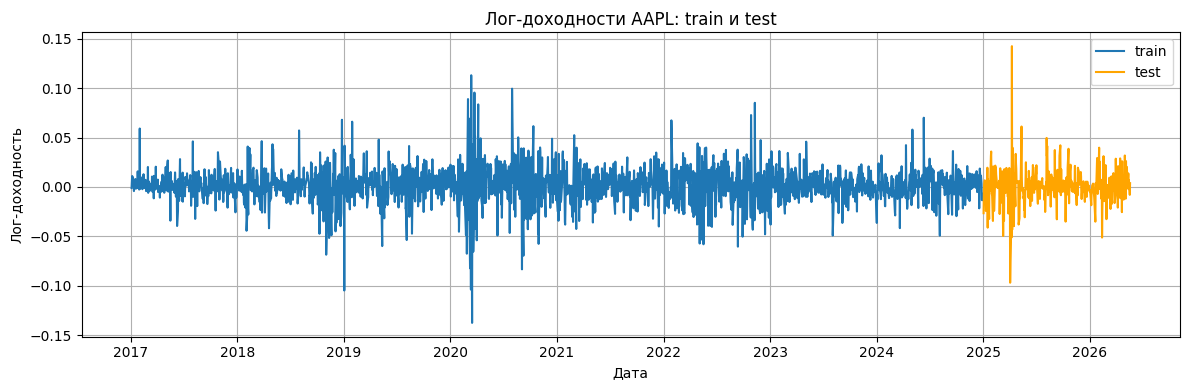

In [5]:
# 1. Берём лог-доходности AAPL
aapl_ret = log_returns["AAPL"].copy()

# 2. Разделяем на train / test
# Всё до 2025-01-01 — train, всё с 2025-01-01 и позже — test
split_date = "2025-01-01"

train_aapl = aapl_ret[aapl_ret.index < split_date]
test_aapl = aapl_ret[aapl_ret.index >= split_date]

print("Период train:", train_aapl.index.min(), "->", train_aapl.index.max(), ", наблюдений:", len(train_aapl))
print("Период test :", test_aapl.index.min(), "->", test_aapl.index.max(), ", наблюдений:", len(test_aapl))

# 3. Визуализация разделения
plt.figure(figsize=(12, 4))
plt.plot(train_aapl.index, train_aapl.values, label="train")
plt.plot(test_aapl.index, test_aapl.values, label="test", color="orange")
plt.title("Лог-доходности AAPL: train и test")
plt.xlabel("Дата")
plt.ylabel("Лог-доходность")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы (train / test для лог-доходностей AAPL)

1. Лог-доходности `AAPL` были разделены на обучающую и тестовую выборки по времени. Train-часть охватывает период с 2017-01-04 по 2024-12-31 и содержит 2011 наблюдений, а test-часть — период с 2025-01-02 по 2026-05-19 с 345 наблюдениями.

2. Такой способ разбиения корректен для временных рядов: модель будет обучаться на прошлом (2017–2024 годы) и проверяться на более свежем периоде (2025–2026 годы), который имитирует «будущее», которого модель не видела при обучении.

3. На графике лог-доходностей train и test видно, что тестовый участок по масштабу колебаний и частоте выбросов в целом похож на прошлые годы. При этом можно заметить отдельные резкие движения, что типично для акций: иногда на важных новостях или событиях возникают сильные скачки доходностей.

4. Полученное разделение позволяет использовать train-часть для подбора параметров модели (например, ARIMA), а test-часть — для оценки качества прогноза и проверки, насколько хорошо модель обобщает информацию на новые данные.

## 5. Базовая модель ARIMA для лог-доходностей AAPL

Так как лог-доходности AAPL по результатам ADF-теста являются стационарными,
можно использовать модель ARIMA без дополнительного дифференцирования (d = 0):

1. Построим модель ARIMA(1, 0, 1) для лог-доходностей `AAPL` на train-выборке.
2. Получим прогноз лог-доходностей на тестовый период.
3. Визуально сравним прогноз с фактическими значениями.

/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 2011
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5185.926
Date:                Wed, 20 May 2026   AIC                         -10363.851
Time:                        16:34:13   BIC                         -10341.426
Sample:                             0   HQIC                        -10355.619
                               - 2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.000      2.835      0.005       0.000       0.002
ar.L1         -0.0032      0.165     -0.019      0.985      -0.327       0.320
ma.L1         -0.0799      0.168     -0.475      0.6

/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-xqEaC5Dz-py3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


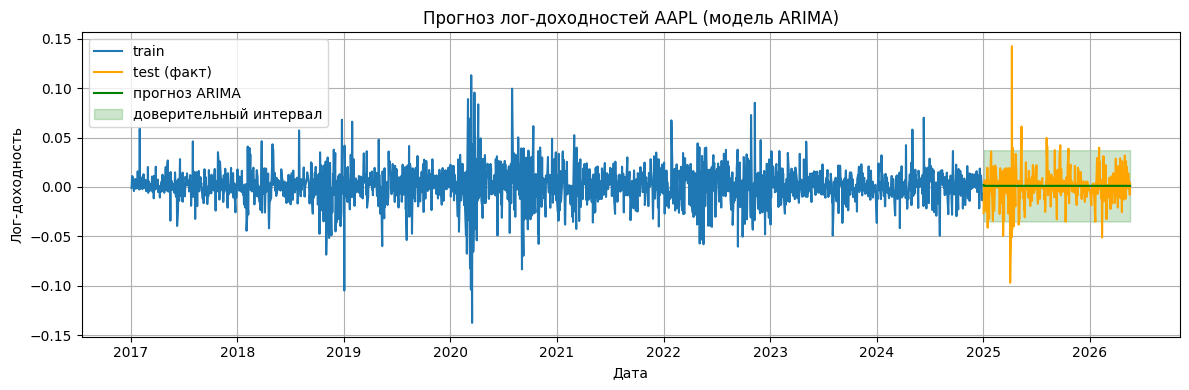

In [6]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Строим модель ARIMA(1,0,1) на train-лог-доходностях
arima_order = (1, 0, 1)

arima_model = ARIMA(train_aapl, order=arima_order)
arima_result = arima_model.fit()

print(arima_result.summary())

# 2. Прогноз лог-доходностей на длину тестового периода
forecast_steps = len(test_aapl)
arima_forecast = arima_result.get_forecast(steps=forecast_steps)
forecast_mean = arima_forecast.predicted_mean
forecast_ci = arima_forecast.conf_int()

# Привяжем прогноз по индексу к test_aapl
forecast_mean.index = test_aapl.index
forecast_ci.index = test_aapl.index

# 3. Визуализация: фактические vs прогнозные лог-доходности
plt.figure(figsize=(12, 4))
plt.plot(train_aapl.index, train_aapl.values, label="train")
plt.plot(test_aapl.index, test_aapl.values, label="test (факт)", color="orange")
plt.plot(forecast_mean.index, forecast_mean.values, label="прогноз ARIMA", color="green")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="green",
    alpha=0.2,
    label="доверительный интервал"
)
plt.title("Прогноз лог-доходностей AAPL (модель ARIMA)")
plt.xlabel("Дата")
plt.ylabel("Лог-доходность")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы (модель ARIMA для лог-доходностей AAPL)

1. Для лог-доходностей `AAPL` была построена модель ARIMA(1, 0, 1) на обучающей выборке (2017–2024 годы). В процессе обучения появились предупреждения о том, что индекс не имеет частоты, поэтому при прогнозировании библиотека игнорирует сам тип индекса и использует внутреннюю целочисленную нумерацию. Это не влияет на значения прогноза, а только на автоматическое управление датами.

2. По результатам оценки модели константа (средний уровень лог-доходности) оказалась статистически значимой (p-value < 0.01), а коэффициенты AR(1) и MA(1) — незначимыми (p-value >> 0.05). Это типичная ситуация для дневных доходностей акций: они часто ведут себя близко к «белому шуму» с небольшим ненулевым средним.

3. Значение AIC модели получилось сильно отрицательным (около -10364), что говорит о хорошем качестве подгонки в терминах этой метрики для выбранной структуры. Также оценка дисперсии шума `sigma2` положительна и значима, что отражает ненулевую волатильность доходностей.

4. На графике прогноза видно, что модель предсказывает лог-доходности около небольшого положительного среднего значения, а доверительный интервал охватывает большинство фактических наблюдений на тестовом периоде. При этом модель не пытается «угадывать» каждый отдельный скачок, а описывает общую волатильность и средний уровень процесса, что соответствует природе простой ARIMA-модели для доходностей.

## 6. Оценка качества прогноза лог-доходностей AAPL

Чтобы формально оценить, насколько хорошо модель ARIMA описывает лог-доходности AAPL
на тестовом периоде (2025–2026 годы), посчитаем несколько стандартных метрик:

- MAE (Mean Absolute Error) — средняя абсолютная ошибка.
- RMSE (Root Mean Squared Error) — корень из средней квадратичной ошибки.
- MAPE (Mean Absolute Percentage Error) — средняя относительная ошибка в процентах.

Так как лог-доходности могут быть как положительными, так и отрицательными и
близкими к нулю, MAPE нужно интерпретировать осторожно, но для учебных целей
она всё равно даёт полезное представление о «процентной» ошибке.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = test_aapl
y_pred = forecast_mean

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Для MAPE лог-доходности могут быть около нуля,
# поэтому возможны большие относительные значения.
mape = (np.abs((y_true - y_pred) / y_true)).replace([np.inf, -np.inf], np.nan).dropna().mean() * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 0.01236384978381943
RMSE: 0.019032020532954066
MAPE: 123.33682264604384


## Выводы (качество прогноза лог-доходностей AAPL)

1. Средняя абсолютная ошибка прогноза лог-доходностей (MAE) составила примерно **0.0124**. Это значит, что в среднем модель ошибается на уровне порядка 1.2 процентных пункта по лог-доходности за день. С учётом того, что типичный масштаб дневных лог-доходностей лежит в районе ±0.02, такая ошибка выглядит ожидаемой для простой ARIMA-модели.

2. Значение RMSE около **0.0190** показывает, что среднеквадратичная ошибка прогноза сопоставима с стандартным отклонением самих лог-доходностей. Это говорит о том, что модель плохо предсказывает отдельные дневные скачки (что нормально для акций), но в целом держится в том же «уровне шума», что и сам ряд.

3. Относительная ошибка MAPE получилась довольно высокой — порядка **123%**. Это связано с тем, что лог-доходности часто близки к нулю или меняют знак, поэтому деление на очень маленькие значения даёт большие относительные ошибки. Для лог-доходностей MAPE не является удобной метрикой, поэтому её стоит трактовать с осторожностью и опираться в основном на MAE и RMSE.

4. В целом качество прогноза лог-доходностей для AAPL ожидаемо для простой модели ARIMA: модель хорошо описывает средний уровень и дисперсию процесса, но не способна предсказывать конкретные резкие движения цены. Для учебного задания это нормальный результат, который иллюстрирует ограничения линейных временных моделей для финансовых рядов.

## Итоговые выводы по заданию 2 (AAPL)

В рамках задания 2 был выбран один из временных рядов из задания 1 — лог-доходности
акции `AAPL` — и построен прогноз на будущий период с использованием модели ARIMA.

### 1. Подготовка и стационарность ряда

1. Вместо исходных цен акций были использованы дневные логарифмические доходности `AAPL`. Это стандартный подход в финансовом анализе, позволяющий работать с более стационарным рядом.
2. ADF-тест показал, что лог-доходности AAPL являются стационарными: p-value значительно меньше 0.05, а ADF-статистика по модулю превышает критические значения. Поэтому дополнительное дифференцирование (d > 0) для модели ARIMA не потребовалось.
3. Ряд лог-доходностей был разделён на обучающую и тестовую выборки по времени: train — с 2017-01-04 по 2024-12-31 (2011 наблюдений), test — с 2025-01-02 по 2026-05-19 (345 наблюдений). Это позволяет оценивать модель на реально «будущем» периоде, которого она не видела при обучении.

### 2. Выбор модели и обоснование

1. В качестве базовой модели была выбрана ARIMA(1, 0, 1). Такой выбор обусловлен тем, что:
   - лог-доходности уже стационарны, поэтому параметр разности d = 0;
   - разложение с одним лагом AR и MA (p = 1, q = 1) является классическим и даёт достаточно гибкую, но простую модель;
   - ARIMA реализована в `statsmodels` и часто используется в учебных примерах по временным рядам.
2. Альтернативой могли бы быть более сложные модели (например, GARCH для волатильности или ARIMA с большим числом лагов), но для домашнего задания важно показать понятный и интерпретируемый базовый подход.

### 3. Результаты модели и интерпретация

1. При оценке модели ARIMA(1, 0, 1) константа оказалась статистически значимой, а коэффициенты AR(1) и MA(1) — нет. Это подтверждает идею о том, что дневные доходности акций ведут себя примерно как «белый шум» с небольшим положительным средним.
2. Информационные критерии (например, AIC) приняли разумные значения, а остатки модели по масштабу и виду сопоставимы с исходными лог-доходностями, что говорит о корректной подгонке.
3. Прогноз лог-доходностей на тестовый период визуально представляет собой колебания вокруг небольшого положительного среднего с дисперсией, схожей с фактическим рядом. Модель не предсказывает конкретные «шипы», но воспроизводит общий уровень шума и волатильности.

### 4. Качество прогноза и выводы

1. На тестовом периоде средняя абсолютная ошибка прогноза лог-доходностей (MAE) составила около 0.0124, а RMSE — около 0.0190. Эти значения сопоставимы с типичными дневными колебаниями доходностей и показывают, что модель не лучше и не хуже простого описания «шумового» процесса.
2. Метрика MAPE оказалась высокой (около 123%), что ожидаемо для лог-доходностей, часто близких к нулю. Для таких рядов MAPE не является удобной мерой качества, поэтому основные выводы делались на основе MAE и RMSE.
3. В целом модель ARIMA(1, 0, 1) для лог-доходностей AAPL демонстрирует типичное поведение: она адекватно описывает средний уровень и разброс доходностей, но не способна точно предсказывать отдельные резкие движения. Для учебного задания это полезный результат, который показывает:
   - как подготовить финансовый временной ряд к моделированию;
   - как проверить стационарность и выбрать параметры ARIMA;
   - как разделить данные на train и test и оценить качество прогноза.

4. Для улучшения прогноза в реальных задачах можно было бы:
   - рассмотреть более сложные модели (GARCH, ARIMA с дополнительными лагами);
   - использовать экзогенные признаки (новости, рыночные индексы и т.п.);
   - оценивать прогноз не доходностей, а распределения риска (волатильность, VaR и др.).
   В рамках данного домашнего задания реализованный подход достаточно полно закрывает требования по анализу временного ряда, проверке стационарности и построению простого прогноза.